# BoundaryST Demonstration: Spatial Transcriptomics & Tumor Boundary Identification

This notebook demonstrates the end-to-end analytical workflow of **BoundaryST**:
1. **Data Preprocessing & Domain Identification:** Loading spatial transcriptomics data and performing initial spatial domain clustering via Mclust.
2. **CNV Profile Estimation:** Quantifying Copy Number Variations (CNV) using a reference normal cluster to distinguish malignant from non-malignant spots.
3. **Tumor Anchor Initialization & Boundary Propagation:** Identifying tumor boundary spots and tracking iterative spatial microenvironment transitions.

## Step 1: Environment Setup & Library Imports

In [1]:
import os
import scanpy as sc
import scanpy.external as sce
import pandas as pd
import numpy as np
import seaborn as sns
import torch
import matplotlib.pyplot as plt
from GraphST import GraphST
import BoundarySP as bd
import BoundarySP_utility

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor='white')

/data1/huanchangxiang/miniconda3/envs/envs/shengxin/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Data Preprocessing & Initial Spatial Domain Identification

Load the spatial transcriptomics dataset (`.h5ad`), run basic preprocessing, and perform initial spatial clustering using `Mclust`.

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes


/data1/huanchangxiang/miniconda3/envs/envs/shengxin/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
... be careful when using `max_value` without `zero_center`.
Begin to train ST data...


100%|████████████████████████████████████████| 600/600 [00:14<00:00, 42.36it/s]


Optimization finished for ST data!


INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /usr/lib/R
INFO:rpy2.situation:R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/java-17-openjdk-amd64/bin/java/lib/server:/usr/local/cuda/lib64:
INFO:rpy2.situation:LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/java-17-openjdk-amd64/bin/java/lib/server:/usr/local/cuda/lib64:
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
INFO:rpy2.rinterface_lib.embedded:R is already initialized. No need to initialize.
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
✅ 成功通过 R 语言 mclust 完成聚类！
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:03)


... storing 'clusters' as categorical


Putative normal cell cluster: 3


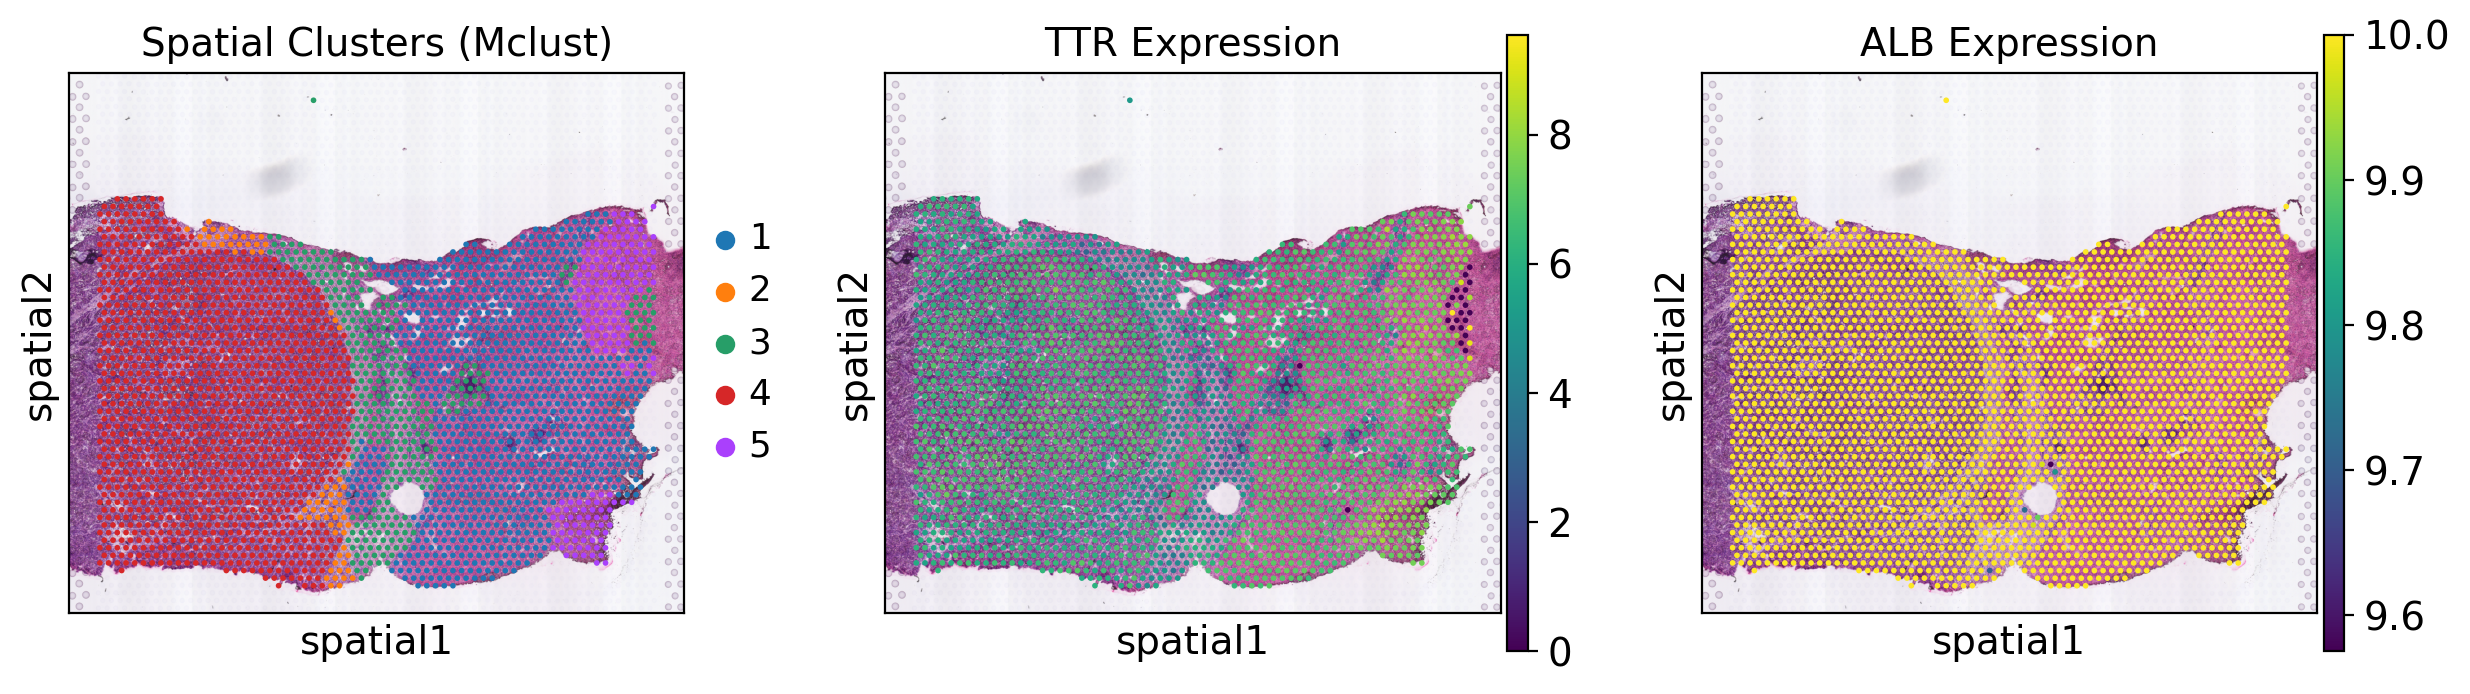

In [2]:
# Set dataset pathways and global parameters
DATASET_ID = 1
SAMPLE_NAME = "HCC-1L"
H5AD_PATH = f"/data1/huanchangxiang/datasets/public_spatial/output/01raw_h5ad/{DATASET_ID}_{SAMPLE_NAME}.h5ad"
GTF_FILE = "/data1/huanchangxiang/software/ref/hg38_index/gencode.v46.annotation.gtf"

# Execute preprocessing and spatial domain clustering
adata = bd.pp.preproboundary(
    type='h5ad',
    path=H5AD_PATH,
    library_id='/HCC1/spatial/',
    n_clusters=5,
    method="mclust",
    radius=20
)

# Visualize identified spatial domains alongside key marker genes (SPP1, COL6A3)
sc.pl.spatial(
    adata, 
    color=["clusters", "TTR", "ALB"], 
    img_key="hires",
    title=["Spatial Clusters (Mclust)", "TTR Expression", "ALB Expression"]
)

## Step 3: CNV Estimation & Malignancy Score Calculation

Estimate single-spot CNV scores using GTF annotations and cluster `4` as the baseline normal reference.

In [3]:
# Infer CNV profile across spatial spots
adata = bd.pp.bdy_cnv(
    adata=adata,
    gtf_file=GTF_FILE,
    reference_cat='3',
    reference_key="clusters",
    resolution=0.4
)

# Rank clusters by mean CNV score to validate malignant vs non-malignant status
cnv_summary = (
    adata.obs.groupby("clusters", observed=False)["cnv_score"]
    .mean()
    .sort_values(ascending=True)
)
print("=== Mean CNV Scores across Clusters ===")
print(cnv_summary)

INFO:root:Extracted GTF attributes: ['gene_id', 'gene_type', 'gene_name', 'level', 'tag', 'transcript_id', 'transcript_type', 'transcript_name', 'transcript_support_level', 'havana_transcript', 'exon_number', 'exon_id', 'hgnc_id', 'havana_gene', 'ont', 'protein_id', 'ccdsid', 'artif_dupl']


100%|████████████████████████████████████████████| 1/1 [00:02<00:00,  2.60s/it]


computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    finished: added to `.uns['cnv_neighbors']`
    `.obsp['cnv_neighbors_distances']`, distances for each pair of neighbors
    `.obsp['cnv_neighbors_connectivities']`, weighted adjacency matrix (0:00:00)
running Leiden clustering
    finished: found 5 clusters and added
    'cnv_leiden', the cluster labels (adata.obs, categorical) (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:03)
=== Mean CNV Scores across Clusters ===
clusters
3    0.021169
1    0.022232
2    0.023044
5    0.024121
4    0.032521
Name: cnv_score, dtype: float64


## Step 4: Iterative Spatial Boundary Identification & Sub-clustering

Run the BoundaryST propagation model to delineate tumor boundaries (`Bdy`) and track progressive spatial transitions from the core outward.

clusters
1    0.022232
2    0.023044
3    0.021169
4    0.032521
5    0.024121
Name: cnv_score, dtype: float64
nbrs_of_Mall is empty. Check the data or the logic that generates it.


... storing 'gene_id' as categorical


Stop at n = 1
Stopped at Step 1


... storing 'gene_name' as categorical


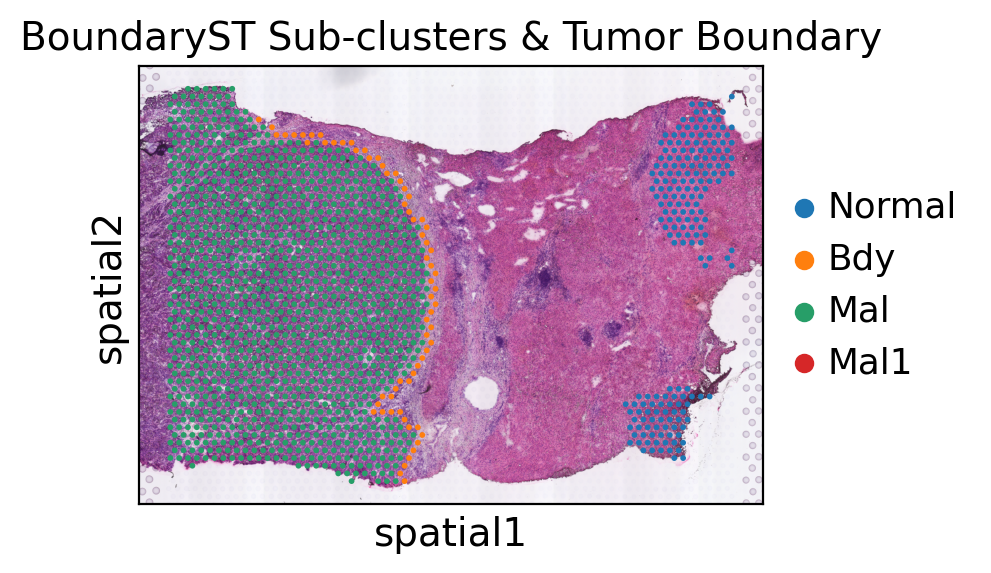

<Figure size 400x400 with 0 Axes>

In [4]:
# Run BoundaryST propagation algorithm
spatial_res, adata = bd.pp.boundary(
    data=adata,
    n_tumor=1,
    selectcluster="5"
)

# Visualize the final tumor boundary and sub-clustering map in spatial coordinates
sc.pl.spatial(
    spatial_res, 
    color="LabelNew", 
    img_key="hires",
    title="BoundaryST Sub-clusters & Tumor Boundary"
)
plt.savefig(
    "/data1/huanchangxiang/Python_script/小论文一/BoundarySpatial/Output//spatial_boundary(Visium).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)